# Zillow Housing Data

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [21]:
zhvi = pd.read_csv("Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv")
income = pd.read_csv("Metro Homeowner Income Downpayment Data.csv")

In [22]:
zhvi.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31
0,102001,0,United States,country,NaN,120245.401273,120456.951481,120719.304889,121282.001451,121929.597731,...,356520.996883,355847.084537,355240.355926,354820.996430,354597.242836,354834.693617,355261.536448,355925.870866,356703.081920,357444.592267
1,394913,1,"New York, NY",msa,NY,216213.074441,217131.858016,218059.151183,219938.205956,221884.032245,...,684527.238403,686280.002733,687742.249805,688904.163124,689687.004711,691074.903618,693389.288933,696701.313817,700090.397649,703126.246109
2,753899,2,"Los Angeles, CA",msa,CA,219357.633964,220173.922681,221261.211467,223424.550904,225790.566038,...,943189.059655,938463.706961,934153.202642,931587.011384,930526.406111,931572.591632,933964.652130,937248.897282,941169.205188,943673.884613
3,394463,3,"Chicago, IL",msa,IL,149975.869412,150114.703378,150379.115111,151036.905792,151828.148861,...,324141.432142,324425.469135,324778.263087,325598.611099,326571.864936,327874.770171,329150.068272,330662.715073,332355.926815,333939.343216
4,394514,4,"Dallas, TX",msa,TX,126453.868825,126510.191820,126574.940868,126743.087346,126964.783873,...,367625.466282,365231.672338,362889.504974,360891.495428,359541.993782,358900.902631,358555.530235,358294.304119,358078.600817,357649.079207


In [23]:
income.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2012-01-31,2012-02-29,2012-03-31,2012-04-30,2012-05-31,...,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31
0,102001,0,United States,country,NaN,36559.835514,36490.877483,36724.770872,36680.231190,36457.452648,...,97109.144895,97639.022416,97501.324725,96683.362100,95646.180919,94272.295098,93651.454126,93693.584911,93529.773490,93060.778596
1,394913,1,"New York, NY",msa,NY,95223.265131,94852.489497,95283.051245,95118.716877,94575.491984,...,197258.579163,199084.973659,199520.417374,198441.935046,196738.576905,194052.884711,193255.861666,193904.363203,194117.034108,193649.093726
2,753899,2,"Los Angeles, CA",msa,CA,78468.301332,77983.158324,77899.253298,77145.377622,76190.773103,...,239925.698815,240586.578787,239548.212564,236999.955387,234140.233151,230104.162326,228761.809902,229222.043739,229221.579648,228101.905446
3,394463,3,"Chicago, IL",msa,IL,45758.338458,45356.903287,45356.452952,45046.965888,44566.059699,...,106904.672109,107630.817007,107756.035485,107358.889285,106757.052759,105825.440337,105538.792804,105882.190190,106061.827730,105929.751547
4,394514,4,"Dallas, TX",msa,TX,38053.857377,38026.340137,38301.186802,38335.697318,38178.471625,...,107640.101316,107731.584881,107128.245070,105885.368808,104541.852157,103078.048185,102259.928641,102075.321353,101667.184019,100910.400705


In [24]:
# Transpose both datasets so each date is a new row
const_cols = ["RegionID", "SizeRank", "RegionName", "RegionType", "StateName"] #Columns to be kept constant

# Melt so each date becomes a row
income_long = income.melt(id_vars=const_cols, var_name="date", value_name="IncomeNeeded")
zhvi_long   = zhvi.melt(id_vars=const_cols, var_name="date", value_name="HomeValue")

In [25]:
income_long

,RegionID,SizeRank,RegionName,RegionType,StateName,date,IncomeNeeded
0,102001,0,United States,country,NaN,2012-01-31,36559.835514
1,394913,1,"New York, NY",msa,NY,2012-01-31,95223.265131
2,753899,2,"Los Angeles, CA",msa,CA,2012-01-31,78468.301332
3,394463,3,"Chicago, IL",msa,IL,2012-01-31,45758.338458
4,394514,4,"Dallas, TX",msa,TX,2012-01-31,38053.857377
...,...,...,...,...,...,...,...
65905,394787,518,"Lewiston, ID",msa,ID,2026-01-31,91116.898591
65906,394570,523,"Enid, OK",msa,OK,2026-01-31,42322.238524
65907,395199,525,"Walla Walla, WA",msa,WA,2026-01-31,102928.837018
65908,394444,551,"Carson City, NV",msa,NV,2026-01-31,111422.522125


In [26]:
zhvi_long

,RegionID,SizeRank,RegionName,RegionType,StateName,date,HomeValue
0,102001,0,United States,country,NaN,2000-01-31,120245.401273
1,394913,1,"New York, NY",msa,NY,2000-01-31,216213.074441
2,753899,2,"Los Angeles, CA",msa,CA,2000-01-31,219357.633964
3,394463,3,"Chicago, IL",msa,IL,2000-01-31,149975.869412
4,394514,4,"Dallas, TX",msa,TX,2000-01-31,126453.868825
...,...,...,...,...,...,...,...
280130,753929,935,"Zapata, TX",msa,TX,2026-01-31,120152.961773
280131,394743,936,"Ketchikan, AK",msa,AK,2026-01-31,380279.892248
280132,753874,937,"Craig, CO",msa,CO,2026-01-31,295377.503197
280133,395188,938,"Vernon, TX",msa,TX,2026-01-31,88441.422656


In [27]:
# Data Cleaning
# Check for missing values in the income and home value columns
print("Rows with missing values in 'IncomeNeeded': ", income_long["IncomeNeeded"].isnull().sum())
print("Rows with missing values in 'HomeValue': ", zhvi_long["HomeValue"].isnull().sum())

Rows with missing values in 'IncomeNeeded':  194
Rows with missing values in 'HomeValue':  49266


In [28]:
# Remove rows with missing value in income and home value columns
income_long.dropna(subset=["IncomeNeeded"], inplace=True)
zhvi_long.dropna(subset=["HomeValue"], inplace=True)

print("Rows with missing values in 'IncomeNeeded': ", income_long["IncomeNeeded"].isnull().sum())
print("Rows with missing values in 'HomeValue': ", zhvi_long["HomeValue"].isnull().sum())

# Remove national row as only looking at individual metros
income_metro = income_long[income_long["RegionType"] == "msa"]
zhvi_metro   = zhvi_long[zhvi_long["RegionType"] == "msa"]

Rows with missing values in 'IncomeNeeded':  0
Rows with missing values in 'HomeValue':  0


In [29]:
# Merge datasets with inner join
merged = pd.merge(zhvi_metro, income_metro[["RegionID", "date", "IncomeNeeded"]], on=["RegionID", "date"], how="inner")

merged["PriceToIncomeRatio"] = merged["HomeValue"] / merged["IncomeNeeded"]

merged['date'] = pd.to_datetime(merged['date'])

print(merged.shape) #65530 rows made it through the cleaning and inner join. The zhvi started in 2000 while the income dataset started in 2012, so the earlier values where lost.
merged.head(10)

(65530, 9)


,RegionID,SizeRank,RegionName,RegionType,StateName,date,HomeValue,IncomeNeeded,PriceToIncomeRatio
0,394913,1,"New York, NY",msa,NY,2012-01-31,371442.639080,95223.265131,3.900755
1,753899,2,"Los Angeles, CA",msa,CA,2012-01-31,365497.086289,78468.301332,4.657895
2,394463,3,"Chicago, IL",msa,IL,2012-01-31,166460.690528,45758.338458,3.637822
3,394514,4,"Dallas, TX",msa,TX,2012-01-31,140189.453419,38053.857377,3.683975
4,394692,5,"Houston, TX",msa,TX,2012-01-31,140825.845304,44076.925915,3.195002
5,395209,6,"Washington, DC",msa,VA,2012-01-31,310066.492159,63775.538953,4.861840
6,394974,7,"Philadelphia, PA",msa,PA,2012-01-31,196518.223864,47656.966523,4.123599
7,394856,8,"Miami, FL",msa,FL,2012-01-31,146881.887990,38879.212241,3.777903
8,394347,9,"Atlanta, GA",msa,GA,2012-01-31,126973.029382,28714.801095,4.421867
9,394404,10,"Boston, MA",msa,MA,2012-01-31,311391.286077,70787.383144,4.398966


In [30]:
# Choose top 9 metro areas to focus on
METROS = [
    "New York, NY", "Los Angeles, CA", "Chicago, IL",
    "Dallas, TX", "Houston, TX", "Washington, DC",
    "Philadelphia, PA", "Miami, FL", "Atlanta, GA", "Boston, MA"
]
house10 = merged[merged["RegionName"].isin(METROS)]
house10.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,date,HomeValue,IncomeNeeded,PriceToIncomeRatio
0,394913,1,"New York, NY",msa,NY,2012-01-31,371442.639080,95223.265131,3.900755
1,753899,2,"Los Angeles, CA",msa,CA,2012-01-31,365497.086289,78468.301332,4.657895
2,394463,3,"Chicago, IL",msa,IL,2012-01-31,166460.690528,45758.338458,3.637822
3,394514,4,"Dallas, TX",msa,TX,2012-01-31,140189.453419,38053.857377,3.683975
4,394692,5,"Houston, TX",msa,TX,2012-01-31,140825.845304,44076.925915,3.195002


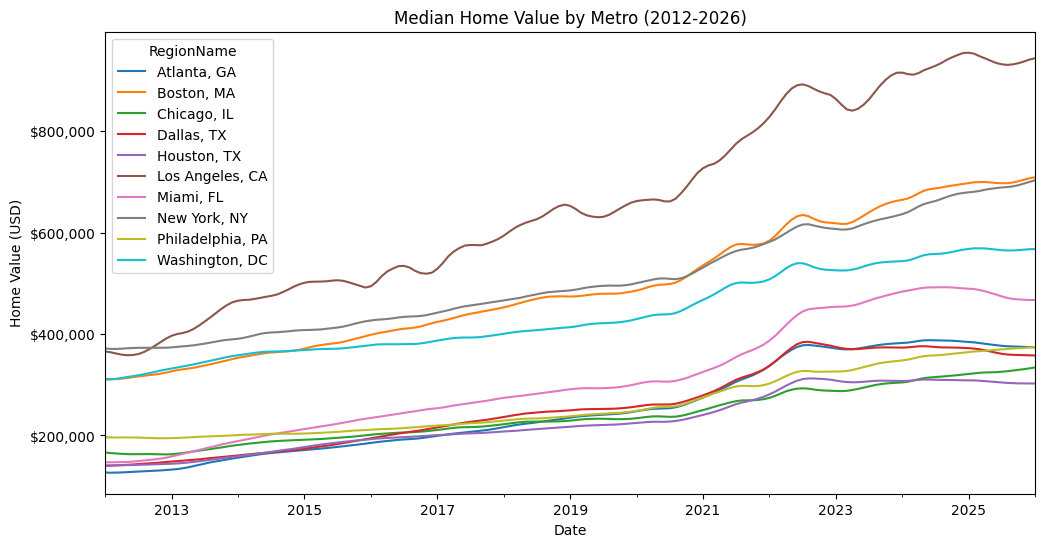

In [31]:
# How has the ZHVI estimate changed over time for major metro areas
house10.pivot(index="date", columns="RegionName", values="HomeValue").plot(figsize=(12, 6))
plt.title("Median Home Value by Metro (2012-2026)")
plt.xlabel("Date")
plt.ylabel("Home Value (USD)")
plt.gca().yaxis.set_major_formatter("${x:,.0f}")
plt.show()

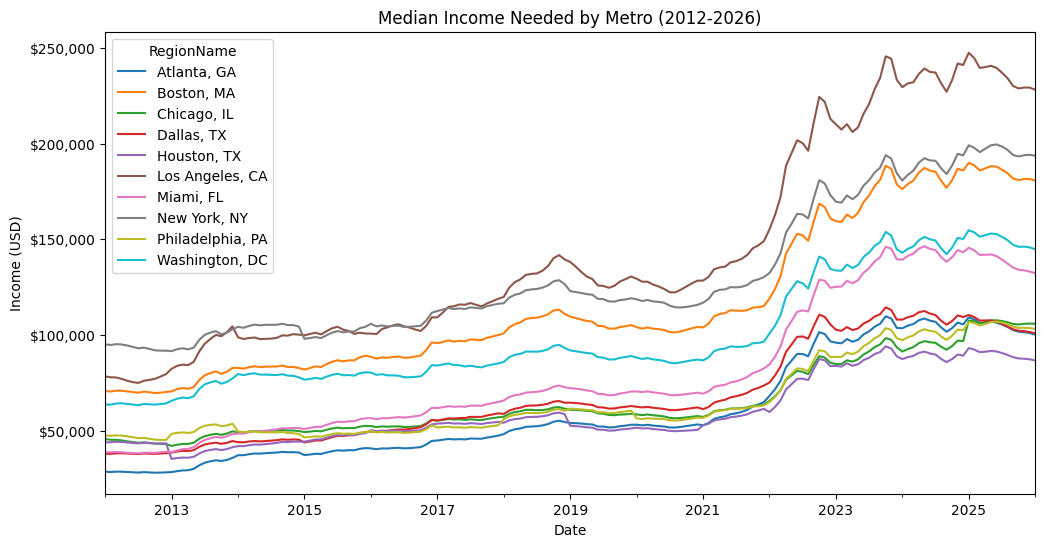

In [32]:
# How has the income needed changed over time for major metro areas
house10.pivot(index="date", columns="RegionName", values="IncomeNeeded").plot(figsize=(12, 6))
plt.title("Median Income Needed by Metro (2012-2026)")
plt.xlabel("Date")
plt.ylabel("Income (USD)")
plt.gca().yaxis.set_major_formatter("${x:,.0f}")
plt.show()

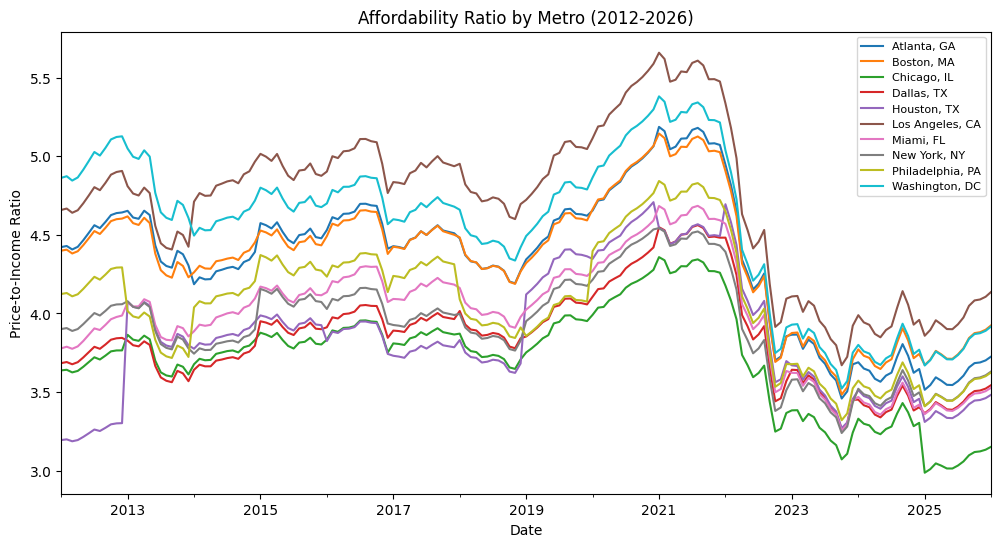

In [33]:
# How has the affordability changed over time for major metro areas
house10.pivot(index="date", columns="RegionName", values="PriceToIncomeRatio").plot(figsize=(12, 6))
plt.title("Affordability Ratio by Metro (2012-2026)")
plt.xlabel("Date")
plt.ylabel("Price-to-Income Ratio")
plt.legend(fontsize=8)
plt.show()

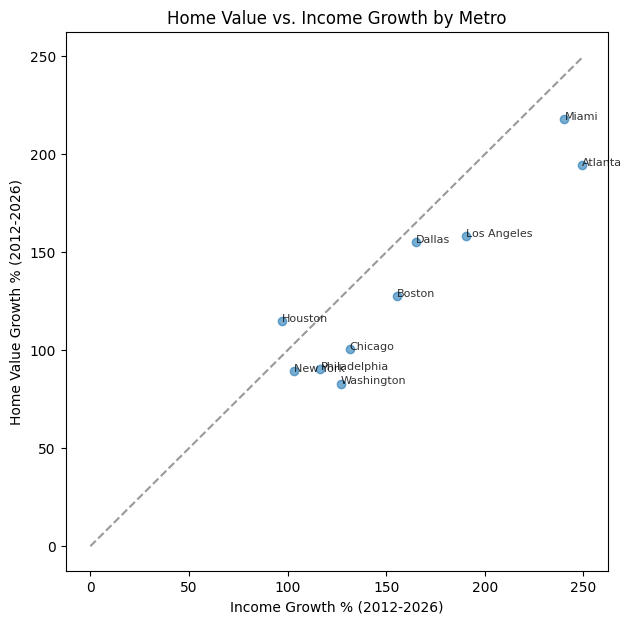

In [40]:
# Ratio of % growth in home value in income over time
def calc_growth(xx):
    return pd.Series({
        "Home_Growth": (xx["HomeValue"].iloc[-1] - xx["HomeValue"].iloc[0]) / xx["HomeValue"].iloc[0] * 100, #percent change = (latest-earliest)/earliest*100
        "Income_Growth": (xx["IncomeNeeded"].iloc[-1] - xx["IncomeNeeded"].iloc[0]) / xx["IncomeNeeded"].iloc[0] * 100
    })

growth = house10[["RegionName", "date", "HomeValue", "IncomeNeeded"]].groupby("RegionName").apply(calc_growth, include_groups=False).reset_index()
plt.figure(figsize=(7, 7))
plt.scatter(growth["Income_Growth"], growth["Home_Growth"], alpha=0.6)
plt.plot([0, 250], [0, 250], "k--", alpha=0.4)

for _, row in growth.iterrows():
    plt.annotate(row["RegionName"].split(",")[0], (row["Income_Growth"], row["Home_Growth"]), fontsize=8, alpha=0.8)
plt.xlabel("Income Growth % (2012-2026)")
plt.ylabel("Home Value Growth % (2012-2026)")
plt.title("Home Value vs. Income Growth by Metro")
plt.show()

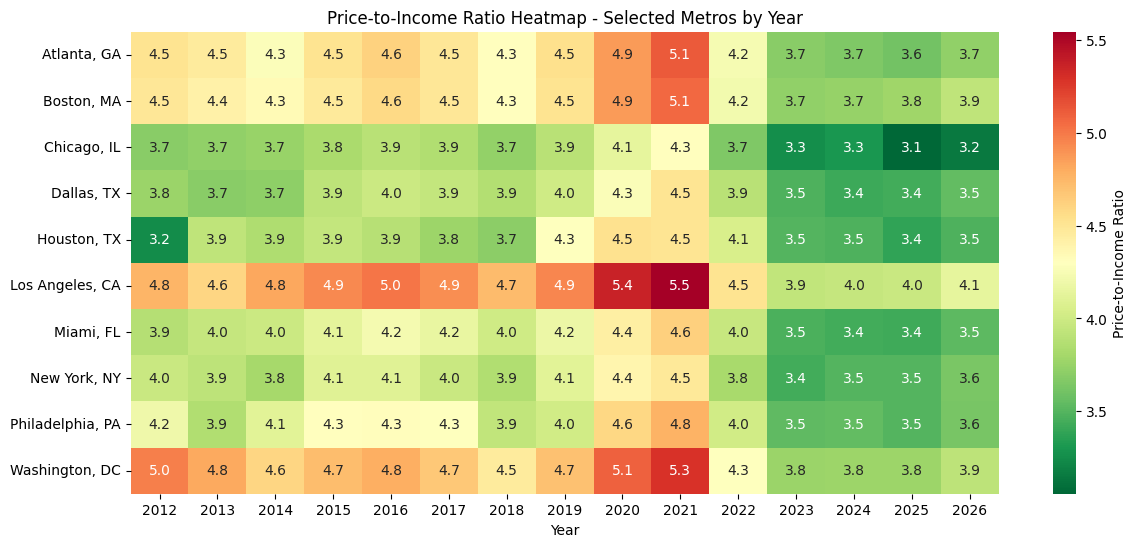

In [56]:
# Heat map of affordablility
heat_df = house10.copy()
heat_df["date"] = pd.to_datetime(heat_df["date"])
heat_df["Year"] = heat_df["date"].dt.year
pivot = heat_df.groupby(["RegionName", "Year"])["PriceToIncomeRatio"].mean().unstack()
plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap="RdYlGn_r", annot=True, fmt=".1f", cbar_kws={"label": "Price-to-Income Ratio"})
plt.title("Price-to-Income Ratio Heatmap - Selected Metros by Year")
plt.xlabel("Year")
plt.ylabel("")
plt.show()

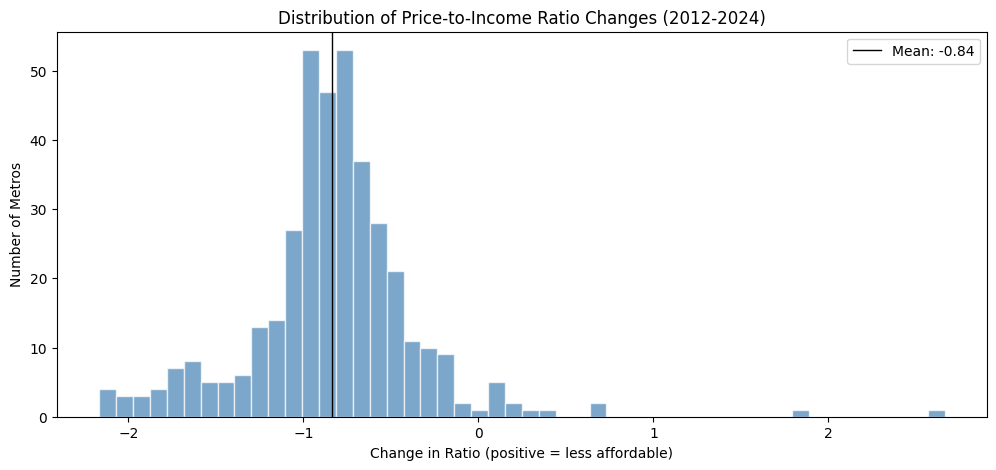

In [49]:
# Distribution of price-to-income ratio changes
snapshot = merged[merged["date"].dt.year.isin([2012, 2024])]
snapshot = snapshot.groupby(["RegionName", snapshot["date"].dt.year])["PriceToIncomeRatio"].mean().unstack()
changes = snapshot[2024] - snapshot[2012]

plt.figure(figsize=(12, 5))
plt.hist(changes, bins=50, color="steelblue", edgecolor="white", alpha=0.7)
plt.axvline(changes.mean(), color="black", linestyle="-", linewidth=1, label=f"Mean: {changes.mean():.2f}")
plt.title("Distribution of Price-to-Income Ratio Changes (2012-2024)")
plt.xlabel("Change in Ratio (positive = less affordable)")
plt.ylabel("Number of Metros")
plt.legend()
plt.show()

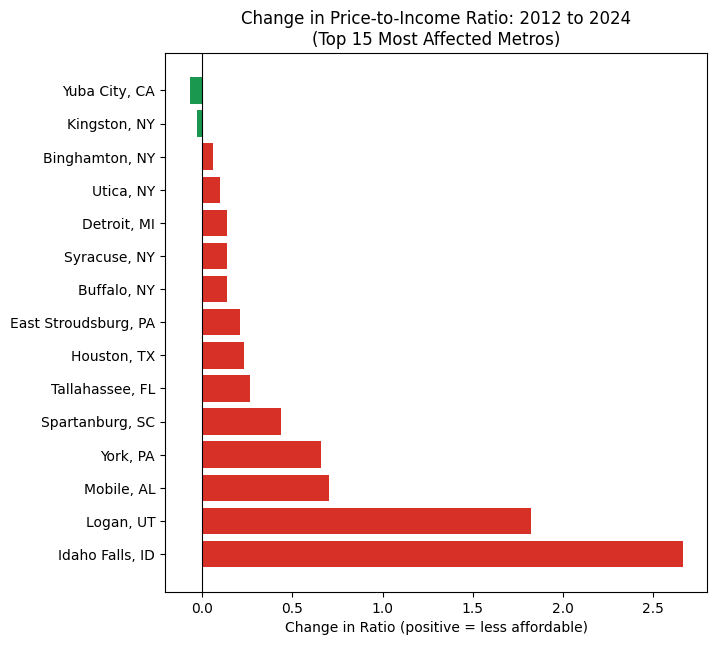

In [52]:
# Change in price-to-income ratio from 2012 to 2024
snapshot = merged[merged["date"].dt.year.isin([2012, 2024])]
snapshot = snapshot.groupby(["RegionName", snapshot["date"].dt.year])["PriceToIncomeRatio"].mean().unstack()
snapshot.columns = [2012, 2024]
snapshot["change"] = snapshot[2024] - snapshot[2012]
top = snapshot.nlargest(15, "change")

colors = []
for x in top["change"]:
    if x > 0:
        colors.append("#d73027")
    else:
        colors.append("#1a9850")
plt.figure(figsize=(7, 7))
plt.barh(top.index, top["change"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Change in Price-to-Income Ratio: 2012 to 2024\n(Top 15 Most Affected Metros)")
plt.xlabel("Change in Ratio (positive = less affordable)")
plt.show()

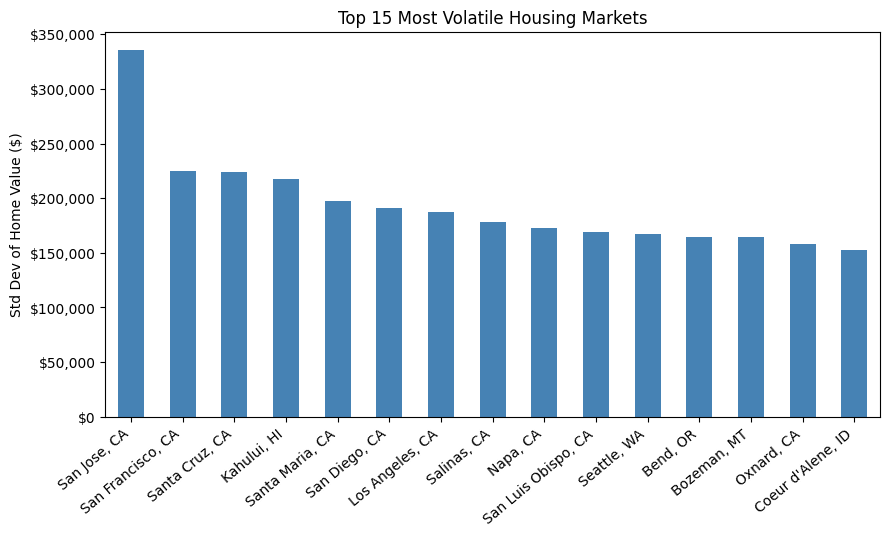

In [55]:
# Top 10 most volatile housing markets
volatility = merged.groupby("RegionName")["HomeValue"].std().nlargest(15)
volatility.plot(kind="bar", figsize=(10, 5), color="steelblue")
plt.gca().yaxis.set_major_formatter("${x:,.0f}")
plt.title("Top 15 Most Volatile Housing Markets")
plt.ylabel("Std Dev of Home Value ($)")
plt.xlabel("")
plt.xticks(rotation=40, ha="right")
plt.show()